In [1]:
import pandas as pd
import sqlite3

#Tabla de Juegos y Ventas
datos_juegos = {
    "ID_Juego" : [1,2,3,4],
    "Nombre_Juego" : ["Wii Sports", "Super Mario Bros", "Mario Kart 8", "Halo 3"],
    "Ventas_Millones" : [82.9, 40.2, 60.5, 14.5],
    "ID_Consola" : [10, 11, 12, 13]
}

#Tabla de Consolas
datos_consolas = {
    "ID_Consola" : [10, 11, 12, 13],
    "Nombre_Consola" : ["Wii", "NES", "Switch", "Xbox 360"],
    "Compañia" : ["Nintendo", "Nintendo", "Nintendo", "Microsoft"]
}

#Creamos las tablas
df_juegos = pd.DataFrame(datos_juegos)
df_consolas = pd.DataFrame(datos_consolas)

#Guardamos en SQL
conexion = sqlite3.connect(":memory:")
df_juegos.to_sql("tabla_juegos", conexion, index=False)
df_consolas.to_sql("tabla_consolas", conexion, index=False)

print("Listo para consulta de tablas")

Listo para consulta de tablas


In [ ]:
#Se sigue la siguiente instrucción para ejecutrar:
#"Necesito un reporte claro. Quiero ver una tabla que tenga el Nombre del Juego, sus Ventas en Millones, y el Nombre de la Consola en la que salió"
"""
SELECT tabla_juegos.Nombre_juego, tabla_juegos.Ventas_Millones, tabla_consolas.Nombre_Consola

"""

'\nSELECT tabla_juegos.Nombre_juego, tabla_juegos.Ventas_Millones, tabla_consolas.Nombre_Consola\n'

In [6]:
query_juegos = """
SELECT tabla_juegos.Nombre_juego, tabla_juegos.Ventas_Millones, tabla_consolas.Nombre_Consola
FROM tabla_juegos
INNER JOIN tabla_consolas ON tabla_juegos.ID_Consola = tabla_consolas.ID_Consola
"""

reporte_ventas = pd.read_sql(query_juegos, conexion)

print("Reporte de Ventas Retrodata Games")
print(reporte_ventas)

Reporte de Ventas Retrodata Games
       Nombre_Juego  Ventas_Millones Nombre_Consola
0        Wii Sports             82.9            Wii
1  Super Mario Bros             40.2            NES
2      Mario Kart 8             60.5         Switch
3            Halo 3             14.5       Xbox 360


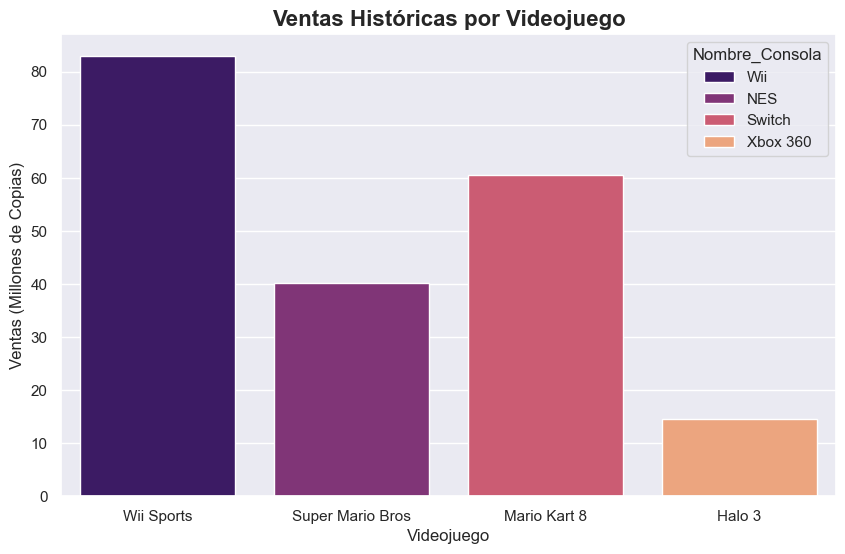

In [7]:
#Realizamos una gráfica
import matplotlib.pyplot as plt
import seaborn as sns

#Estilo con fondo oscuro
sns.set_theme(style="darkgrid")

#El tamaño
plt.figure(figsize=(10, 6))

#La construcción del gráfico
sns.barplot(
    data= reporte_ventas,
    x= "Nombre_Juego",
    y= "Ventas_Millones",
    hue= "Nombre_Consola",
    dodge= False,
    palette= "magma"
)

#Se complementa con los títulos
plt.title("Ventas Históricas por Videojuego", fontsize = 16, fontweight = "bold")
plt.xlabel("Videojuego", fontsize = 12)
plt.ylabel("Ventas (Millones de Copias)", fontsize = 12)

plt.show()